### Setup

In [193]:
import pandas as pd

# โหลดไฟล์ Excel (เปลี่ยนเป็นชื่อไฟล์ของคุณ)
df = pd.read_csv("data.csv")
df = df.dropna()
sub = pd.read_csv("data.csv", header=1)

# ดูตัวอย่างข้อมูล
df.head()
# sub.head()



,Age,Gender,คณะ,สาขา,Drink Type,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,ปริมาณที่ดื่มต่อครั้ง (เหล้า),ปริมาณที่ดื่มต่อครั้ง (เบียร์),ความถี่ในการดื่ม ครั้งต่อเดือน,สถานที่ที่ดื่มบ่อย,Unnamed: 13,Unnamed: 14,Unnamed: 15,ช่วงเวลาที่ดื่ม,Unnamed: 17,Cost(thb)
1,21.0,ชาย,คณะวิศวกรรมศาสตร์,วิศวระบบขนส่งทางราง,0,1,0,0,0,0 แก้ว,6 แก้ว,2.0,0,0,0,1,0,1,100 - 200
2,22.0,หญิง,คณะวิศวกรรมศาสตร์,วิศวกรรมระบบไอโอทีและสารสนเทศ และฟิสิกส์อุตสาห...,1,1,0,0,0,28 แก้ว,6 แก้ว,5.0,1,0,0,0,1,1,200 - 300
3,19.0,หญิง,คณะวิศวกรรมศาสตร์,วิศวกรรมระบบไอโอทีและสารสนเทศ,1,1,0,0,0,0 แก้ว,9 แก้ว,1.0,1,0,0,0,0,1,200 - 300
4,22.0,หญิง,คณะวิศวกรรมศาสตร์,วิศวกรรมระบบไอโอทีและสารสนเทศ,1,1,1,1,0,5 แก้ว,5 แก้ว,1.0,1,0,1,1,1,1,400 - 500
5,20.0,ชาย,คณะวิศวกรรมศาสตร์,ไฟฟ้าสื่อสารและอิเล็กทรอนิกส์,1,1,0,0,0,70 แก้ว,15 แก้ว,2.0,1,0,1,1,0,1,200 - 300


### 1.สัดส่วนประเภทเครื่องดื่มที่ดื่มบ่อย

In [194]:
# เลือกคอลัมน์ E ถึง I (แก้ไขชื่อคอลัมน์ให้ตรงกับไฟล์ของคุณ)
df_selected = sub.iloc[:, 4:9]  # E-I คือ คอลัมน์ที่ 4 ถึง 8 (นับจาก 0)


# รวมค่าทั้งหมดในแต่ละคอลัมน์
drink_counts = df_selected.sum()
print(drink_counts)



alcohol       36
beer          43
cocktail      18
wine          13
soft drink     5
dtype: int64


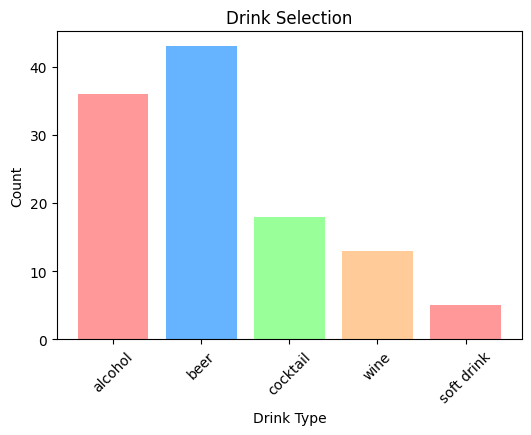

In [195]:
import matplotlib.pyplot as plt

# ตั้งค่าขนาดกราฟ
plt.figure(figsize=(6, 4))

# สร้าง Bar Chart
plt.bar(drink_counts.index, drink_counts.values, color=['#ff9999','#66b3ff','#99ff99','#ffcc99'])

# ตั้งชื่อกราฟ
plt.title("Drink Selection")
plt.xlabel("Drink Type")
plt.ylabel("Count")

# ตั้งค่า Label ให้ใช้จาก index ของ drink_counts
plt.xticks(rotation=45)  # ให้ Label หมุน 45 องศา

# แสดงกราฟ
plt.show()


### 2.ความถี่ในการดื่ม vs. ปริมาณที่ดื่ม

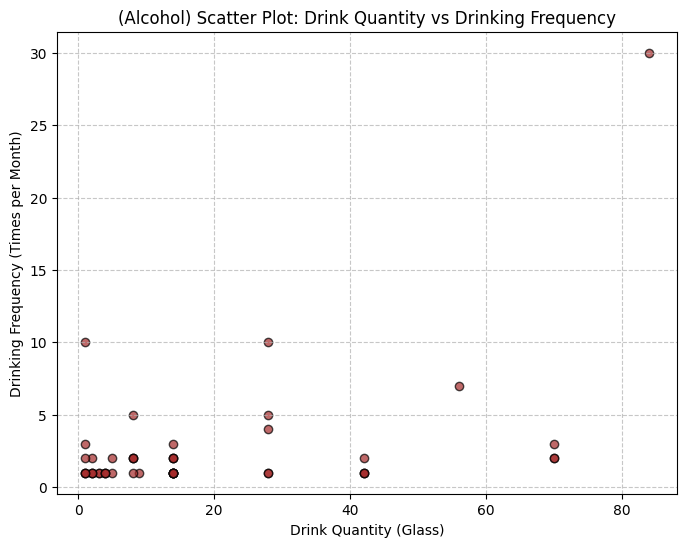

In [196]:
import matplotlib.pyplot as plt

df = pd.read_csv("data.csv")
df = df.dropna()
sub = pd.read_csv("data.csv", header=1)

# แปลงข้อมูลให้เป็นตัวเลข
df_filtered = df[df['ปริมาณที่ดื่มต่อครั้ง (เหล้า)'] != "0 แก้ว"]
quantity_column = df_filtered['ปริมาณที่ดื่มต่อครั้ง (เหล้า)'].str.replace(' แก้ว', '').astype(float)
frequency_column = df_filtered['ความถี่ในการดื่ม ครั้งต่อเดือน'].astype(int)

plt.figure(figsize=(8, 6))

# สร้าง Scatter Plot
plt.scatter(quantity_column, frequency_column, alpha=0.7, color='brown', edgecolor='black')

# ตั้งค่าชื่อ
plt.title("(Alcohol) Scatter Plot: Drink Quantity vs Drinking Frequency")
plt.xlabel("Drink Quantity (Glass)")
plt.ylabel("Drinking Frequency (Times per Month)")

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()



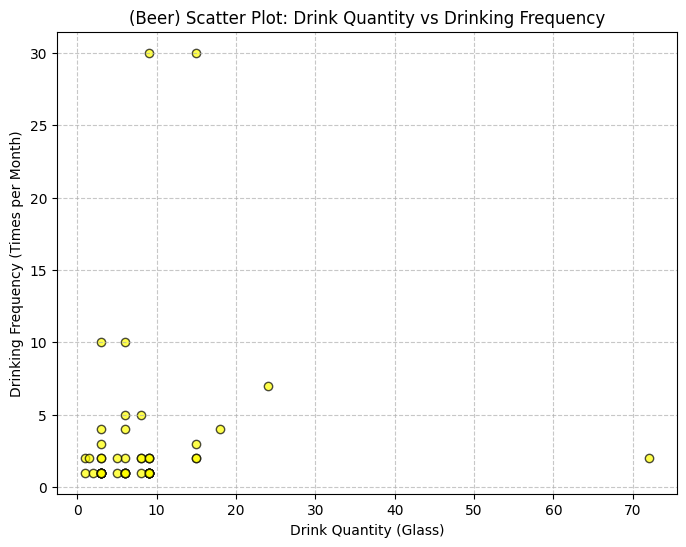

In [197]:
import matplotlib.pyplot as plt

df = pd.read_csv("data.csv")
df = df.dropna()
sub = pd.read_csv("data.csv", header=1)

# แปลงข้อมูลให้เป็นตัวเลข
df_filtered = df[df['ปริมาณที่ดื่มต่อครั้ง (เบียร์)'] != "0 แก้ว"]
quantity_column = df_filtered['ปริมาณที่ดื่มต่อครั้ง (เบียร์)'].str.replace(' แก้ว', '').astype(float)
frequency_column = df_filtered['ความถี่ในการดื่ม ครั้งต่อเดือน'].astype(int)

plt.figure(figsize=(8, 6))

# สร้าง Scatter Plot
plt.scatter(quantity_column, frequency_column, alpha=0.7, color='yellow', edgecolor='black')

# ตั้งค่าชื่อ
plt.title("(Beer) Scatter Plot: Drink Quantity vs Drinking Frequency")
plt.xlabel("Drink Quantity (Glass)")
plt.ylabel("Drinking Frequency (Times per Month)")

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


### 3.ความสัมพันธ์ของสถานที่ที่ดื่มกับช่วงเวลาที่ดื่ม

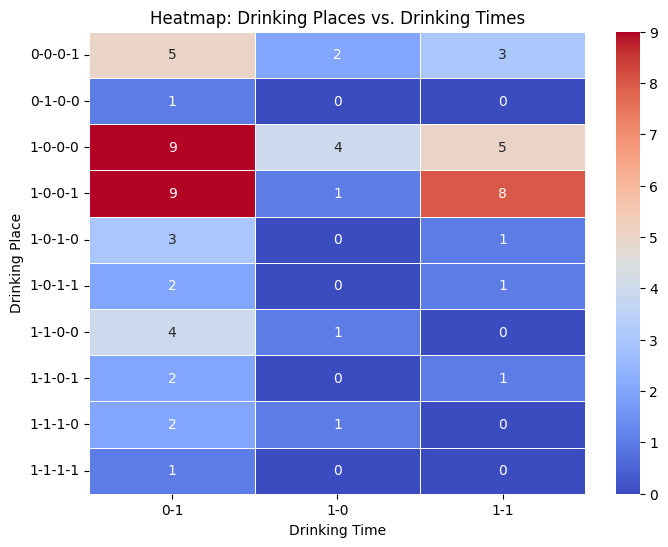

In [198]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# สมมติว่าคอลัมน์ที่เกี่ยวข้องมีชื่อตามนี้
place_column = "ร้านนั่งชิลล์", "ผับ", "บาร์", "ซื้อกลับไปกินที่บ้าน/หอ" # (สถานที่ที่ดื่มบ่อย)

time_column = "วันธรรมดา", "วันหยุด" # (ช่วงเวลาที่ดื่ม)

# สร้างตาราง Pivot Table
heatmap_data = sub.pivot_table(index=place_column, columns=time_column, aggfunc='size', fill_value=0)

# สร้าง Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", linewidths=0.5, fmt="d")

# ตั้งค่าชื่อแกน
plt.title("Heatmap: Drinking Places vs. Drinking Times")
plt.xlabel("Drinking Time")
plt.ylabel("Drinking Place")

plt.xticks(rotation=0)  # ทำให้แกน X อ่านง่ายขึ้น
plt.yticks(rotation=0)  # ทำให้แกน Y อ่านง่ายขึ้น

plt.show()

#### Heatmap: สถานที่ดื่ม vs. ช่วงเวลาดื่ม (Binary)

**แกน X (ช่วงเวลาดื่ม):**

* 0-1 = วันธรรมดา
* 1-0 = วันหยุด
* 1-1 = ทั้งวันธรรมดาและวันหยุด

**แกน Y (สถานที่ดื่ม):**

* 0-0-0-0 = ไม่ดื่มที่ร้านนั่งชิลล์, ผับ, บาร์, ซื้อกลับไปกินที่บ้าน/หอ
* 0-0-0-1 = ซื้อกลับไปกินที่บ้าน/หอ
* 0-0-1-0 = บาร์
* 0-0-1-1 = บาร์, ซื้อกลับไปกินที่บ้าน/หอ
* 0-1-0-0 = ผับ
* 0-1-0-1 = ผับ, ซื้อกลับไปกินที่บ้าน/หอ
* 0-1-1-0 = ผับ, บาร์
* 0-1-1-1 = ผับ, บาร์, ซื้อกลับไปกินที่บ้าน/หอ
* 1-0-0-0 = ร้านนั่งชิลล์
* 1-0-0-1 = ร้านนั่งชิลล์, ซื้อกลับไปกินที่บ้าน/หอ
* 1-0-1-0 = ร้านนั่งชิลล์, บาร์
* 1-0-1-1 = ร้านนั่งชิลล์, บาร์, ซื้อกลับไปกินที่บ้าน/หอ
* 1-1-0-0 = ร้านนั่งชิลล์, ผับ
* 1-1-0-1 = ร้านนั่งชิลล์, ผับ, ซื้อกลับไปกินที่บ้าน/หอ
* 1-1-1-0 = ร้านนั่งชิลล์, ผับ, บาร์
* 1-1-1-1 = ร้านนั่งชิลล์, ผับ, บาร์, ซื้อกลับไปกินที่บ้าน/หอ

**หมายเหตุ:**

* เลข 0 หมายถึง "ไม่ดื่ม" ที่สถานที่นั้น
* เลข 1 หมายถึง "ดื่ม" ที่สถานที่นั้น
* ลำดับของตัวเลขในแกน Y คือ ร้านนั่งชิลล์, ผับ, บาร์, ซื้อกลับไปกินที่บ้าน/หอ ตามลำดับ

### 4.สัดส่วนประเภทเครื่องดื่มที่ดื่มบ่อย

In [199]:
# reload data
df = pd.read_csv("data.csv")
df = df.dropna()
sub = pd.read_csv("data.csv", header=1)

In [200]:
import pandas as pd
import matplotlib.pyplot as plt

# Remove non-numeric characters and convert to numeric
sub.iloc[:, 9] = sub.iloc[:, 9].str.replace(' แก้ว', '').astype(float)
sub.iloc[:, 10] = sub.iloc[:, 10].str.replace(' แก้ว', '').astype(float)

# คำนวณค่าเฉลี่ย
num_alcohol = df_selected['alcohol'].sum()
average_alcohol_glasses = sub.iloc[:, 9].mean()

# แสดงผลค่าเฉลี่ย
print(f"จำนวนคนที่ดื่มเหล้า: {num_alcohol}")
print(f"ค่าเฉลี่ยจำนวนแก้วที่ดื่ม: {average_alcohol_glasses:.2f} แก้ว")

# คำนวณค่าเฉลี่ย
num_beer = df_selected['beer'].sum()
average_beer_glasses = sub.iloc[:, 10].mean()

# แสดงผลค่าเฉลี่ย
print(f"จำนวนคนที่ดื่มเบียร์: {num_beer}")
print(f"ค่าเฉลี่ยจำนวนแก้วที่ดื่ม: {average_beer_glasses:.2f} แก้ว")


จำนวนคนที่ดื่มเหล้า: 36
ค่าเฉลี่ยจำนวนแก้วที่ดื่ม: 13.68 แก้ว
จำนวนคนที่ดื่มเบียร์: 43
ค่าเฉลี่ยจำนวนแก้วที่ดื่ม: 6.40 แก้ว


In [201]:
# reload data
df = pd.read_csv("data.csv")
df = df.dropna()
sub = pd.read_csv("data.csv", header=1)

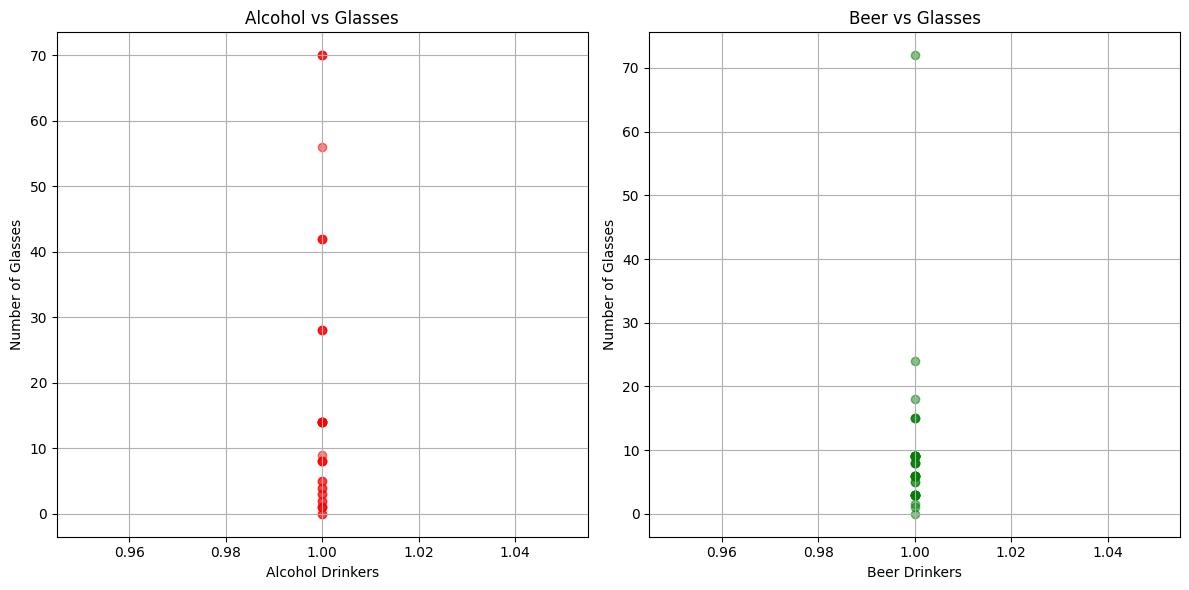

In [202]:
import pandas as pd
import matplotlib.pyplot as plt

# สมมติว่าข้อมูลของคุณอยู่ใน DataFrame ที่ชื่อว่า 'df_selected'
# และมีคอลัมน์ 'alcohol' และ 'beer' (จำนวนคนที่ดื่มแอลกอฮอล์และเบียร์) และ คอลัมน์ที่ 10 และ 11 (จำนวนแก้วที่ดื่มแอลกอฮอล์และเบียร์)

# Sort the y-axis values
sorted_alcohol = sub.iloc[:, 9][df_selected['alcohol'] == 1].str.replace(' แก้ว', '').astype(float).sort_values()
sorted_beer = sub.iloc[:, 10][df_selected['beer'] == 1].str.replace(' แก้ว', '').astype(float).sort_values()

# สร้าง Scatter Plot
plt.figure(figsize=(12, 6))  # เพิ่มขนาดกราฟเพื่อให้เห็นชัดเจน

# Scatter Plot สำหรับ Alcohol
plt.subplot(1, 2, 1)  # แบ่งกราฟเป็น 1 แถว 2 คอลัมน์, เลือก plot แรก
plt.scatter(df_selected['alcohol'][df_selected['alcohol'] == 1], sorted_alcohol, alpha=0.5, color='red')
plt.title('Alcohol vs Glasses')
plt.xlabel('Alcohol Drinkers')
plt.ylabel('Number of Glasses')
plt.grid(True)

# Scatter Plot สำหรับ Beer
plt.subplot(1, 2, 2)  # แบ่งกราฟเป็น 1 แถว 2 คอลัมน์, เลือก plot สอง
plt.scatter(df_selected['beer'][df_selected['beer'] == 1], sorted_beer, alpha=0.5, color='green')
plt.title('Beer vs Glasses')
plt.xlabel('Beer Drinkers')
plt.ylabel('Number of Glasses')
plt.grid(True)

plt.tight_layout()  # ปรับ layout ของกราฟไม่ให้ทับกัน
plt.show()

### 5.ค่าใช้จ่าย vs ปริมาณที่ดื่ม

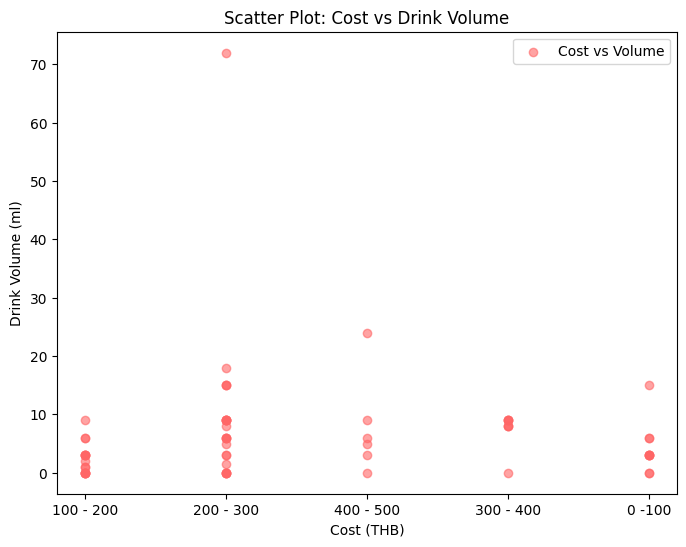

In [203]:
import matplotlib.pyplot as plt

# สมมติว่าข้อมูลอยู่ใน df
x_cost = df['Cost(thb)']
y_volume = df['ปริมาณที่ดื่มต่อครั้ง (เบียร์)'].str.replace(' แก้ว', '').astype(float)  # แปลงเป็น float

# สร้าง Scatter Plot
plt.figure(figsize=(8, 6))
plt.scatter(x_cost, y_volume, alpha=0.6, color="#ff6666", label="Cost vs Volume")

# ตั้งค่า Label
plt.xlabel("Cost (THB)")
plt.ylabel("Drink Volume (ml)")
plt.title("Scatter Plot: Cost vs Drink Volume")
plt.legend()

# 🔄 กลับด้านแกน Y ให้เรียงจากน้อย → มาก
plt.gca()

# แสดงกราฟ
plt.show()

